1. Le Moteur de Décision ((LSTM) & Signal)

La stratégie repose sur un arbitrage de spread piloté par un modèle LSTM (Deep Learning). Au lieu de parier sur un simple retour à la moyenne statistique, le LSTM prédit la valeur future du spread entre le Bitcoin et l'Ethereum. Un Z-Score est calculé pour mesurer l'écart entre la prédiction de lSTM et le prix réel du marché. Si cet écart est important (Z-Score > 1.0), la stratégie considère qu'il y a une opportunité de profit et entre en position. On sort du trade dès que cet écart se résorbe (Z-Score < 0.2), signalant que le profit potentiel a été capturé.

2. Le Système de Contrôle et de Sécurité

Pour protéger le capital contre la volatilité extrême des cryptomonnaies, le code applique trois verrous de sécurité. 

Premièrement, un filtre de volatilité (VIX) bloque toute activité ou ferme les positions si le marché devient trop instable (volatilité 5% au-dessus de sa moyenne). 

Deuxièmement, un Stop-Loss statistique coupe la position si le spread évolue anormalement contre nous (2.5 écarts-types). Enfin, un Time-Stop limite la durée de chaque trade à 6 jours (36 bougies de 4h) pour éviter l'immobilisation du capital dans des positions stagnantes.

Extraction de donnée CCXT

In [31]:
import ccxt
import pandas as pd
import time
import os


#  Mon LE CHEMIN DE SAUVEGARDE DES FICHIERS CSV

path = r"C:/Users/koffi/Downloads/Hedge-fund-trade/"


os.makedirs(path, exist_ok=True)  # Vérifie si le dossier existe, sinon le crée


#  PARAMÈTRES GÉNÉRAUX paramétrable : Ma stratégie est 4h d'écart de trade

exchange_id = 'binance'
timeframe = '4h'           
symbol_eth = 'ETH/USDT'
symbol_btc = 'BTC/USDT'
limit = 1000               # Nombre maximum de barres par appel API

# Début exact  1er janvier 2021

since = int(pd.Timestamp("2021-01-01").timestamp() * 1000)


end_timestamp = int(pd.Timestamp("2026-02-08").timestamp() * 1000)

#  INITIALISATION DE L'EXCHANGE

exchange = getattr(ccxt, exchange_id)({'enableRateLimit': True})


#  FONCTION DE TÉLÉCHARGEMENT DES OHLCV

def fetch_ohlcv(symbol):
    print(f"Téléchargement de {symbol} en {timeframe} ...")
    all_bars = []
    since_arg = since

    while True:
        # On arrête de boucler si notre curseur dépasse déjà la date limite
        if since_arg >= end_timestamp:
            break

        bars = exchange.fetch_ohlcv(
            symbol,
            timeframe=timeframe,
            since=since_arg,
            limit=limit
        )

        if not bars:
            break

        all_bars += bars

        # Mise à jour du timestamp pour le prochain lot
        since_arg = bars[-1][0] + 1

        # Pause pour le rate limit
        time.sleep(exchange.rateLimit / 1000)

        # Stop si le dernier lot reçu dépasse la limite (évite des appels inutiles)
        if bars[-1][0] >= end_timestamp:
            break

    #  TRAITEMENT DU DATAFRAME df4 
    
    df4 = pd.DataFrame(all_bars, columns=['timestamp','open','high','low','close','volume'])
    
    # ÉTAPE CRUCIALE : On filtre pour supprimer les lignes qui dépassent end_timestamp
    # (L'API renvoyant des blocs de 1000, le dernier bloc contient souvent des données en trop)

    df4 = df4[df4['timestamp'] <= end_timestamp]
    
    # Conversion et indexation
    df4['timestamp'] = pd.to_datetime(df4['timestamp'], unit='ms')
    df4 = df4.set_index('timestamp')

    return df4


#  TÉLÉCHARGEMENT ETH & BTC

df_eth4 = fetch_ohlcv(symbol_eth)
df_btc4 = fetch_ohlcv(symbol_btc)


#  SAUVEGARDE DES FICHIERS CSV DANS MON DOSSIER

eth_patho = os.path.join(path, "eth_USDT_4h_.csv")
btc_patho = os.path.join(path, "btc_USDT_4h_.csv")

df_eth4.to_csv(eth_patho)
df_btc4.to_csv(btc_patho)

#  AFFICHAGE DES INFORMATIONS

print("\n RÉSUMÉ DES DONNÉES 4H ")
print("ETH :", df_eth4.index[0], "-", df_eth4.index[-1])
print("BTC :", df_btc4.index[0], "-", df_btc4.index[-1])

print("Taille ETH :", df_eth4.shape)
print("Taille BTC :", df_btc4.shape)

print(f"\nFichiers sauvegardés dans : {path}")


Téléchargement de ETH/USDT en 4h ...
Téléchargement de BTC/USDT en 4h ...

 RÉSUMÉ DES DONNÉES 4H 
ETH : 2021-01-01 00:00:00 - 2026-02-08 00:00:00
BTC : 2021-01-01 00:00:00 - 2026-02-08 00:00:00
Taille ETH : (11185, 5)
Taille BTC : (11185, 5)

Fichiers sauvegardés dans : C:/Users/koffi/Downloads/Hedge-fund-trade/


In [32]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import os


#  CHEMIN DES FICHIERS 

path = r"C:/Users/koffi/Downloads/Hedge-fund-trade/"

eth_path = os.path.join(path, "ETH_USDT_4h.csv")
btc_path = os.path.join(path, "BTC_USDT_4h.csv")


#  CHARGEMENT ET FUSION DES DONNÉES

# S'assurer que les fichiers CSV sont bien formatés

df_eth = pd.read_csv(eth_path, index_col='timestamp', parse_dates=True)
df_btc = pd.read_csv(btc_path, index_col='timestamp', parse_dates=True)

# Prendre uniquement les prix de clôture et les fusionner

prices = pd.merge(
    df_eth['close'].rename('Price_ETH'),
    df_btc['close'].rename('Price_BTC'),
    left_index=True,
    right_index=True,
    how='inner'
)

# Utiliser les logarithmes

prices['log_ETH'] = np.log(prices['Price_ETH'])
prices['log_BTC'] = np.log(prices['Price_BTC'])

#Pour s'assurer que l'index est bien de type DatetimeIndex

if not isinstance(prices.index, pd.DatetimeIndex):
    print("ATTENTION: L'index n'est pas un DatetimeIndex. Vérifiez les fichiers sources.")
    # Tentative de correction si l'erreur vient d'ici
    prices.index = pd.to_datetime(prices.index)





    


Ce code a pour but de mesurer la relation historique entre le Bitcoin et l'Ethereum afin d'isoler un Spread (un écart) exploitable pour le trading.

 
 
 1. Initialisation et Fenêtre Glissante La fonction crée des listes vides pour stocker les résultats et définit une "fenêtre" (ex: 24h). Elle parcourt ensuite l'historique des prix étape par étape. Pour chaque point dans le temps, elle regarde uniquement les n dernières données (la fenêtre) pour s'adapter aux changements récents du marché.
 
 2. Régression Linéaire Dynamique (OLS) À l'intérieur de la boucle, le code effectue une régression linéaire (sm.OLS) entre le log de l'ETH (la cible) et le log du BTC (la référence) :Calcul du Beta : Il détermine le coefficient de corrélation de force entre les deux actifs. Ce Beta n'est pas fixe, il évolue selon la période. Calcul du R² : Il mesure la qualité de la relation. Un R^2 élevé signifie que le BTC explique très bien les mouvements de l'ETH.
 
 3. Extraction du Spread et IndicateursUne fois le Beta calculé pour chaque instant, le code définit le Spread via la formule :Spread = log(ETH) - (beta \times log(BTC)) Cela permet de "neutraliser" le marché : on obtient une courbe qui représente la valeur de l'ETH si le BTC ne bougeait pas.
 4. Enrichissement Statistique Enfin, le code calcule deux indicateurs sur ce spread pour la stratégie :Vol_Spread : La volatilité du spread (pour ajuster les risques). Spread_MA : La moyenne mobile du spread (pour détecter les déviations par rapport à la normale).

In [33]:

#  FONCTION DE COINTÉGRATION GLISSANTE 


def calculate_rolling_coint_features_loop(df, window):
    """Calcule le beta, le spread, et le R2 de cointégration glissante via une boucle."""
    
    # Préparer les colonnes de résultats
    betas = [np.nan] * window
    r2_scores = [np.nan] * window
    
    log_eth = df['log_ETH'].values
    log_btc = df['log_BTC'].values
    
    # 1. Calcul du Beta et R2 Glissants
    
    # On commence la boucle à 'window' pour avoir suffisamment de données

    for i in range(window, len(df)):

        # Définir la fenêtre de données (de i - window à i)
        y = log_eth[i - window : i]
        X = log_btc[i - window : i]
        
        # Ajout de la constante (alpha) pour la régression
        X = sm.add_constant(X, prepend=False) 
        
        try:
            model = sm.OLS(y, X).fit()
            # Le Beta est la première variable (indice 0) si prepend=False
            betas.append(model.params[0]) 
            r2_scores.append(model.rsquared)

        except ValueError:
            # En cas d'erreur (ex: données manquantes dans la fenêtre)
            betas.append(np.nan)
            r2_scores.append(np.nan)
            

    # Ajouter les résultats au DataFrame

    df['Rolling_Beta'] = betas[:len(df)]
    df['Rolling_R2'] = r2_scores[:len(df)]
    
    # 2/ Calcul du Spread Dynamique

    # Spread = log(ETH) - Beta * log(BTC)

    df['Spread'] = df['log_ETH'] - df['Rolling_Beta'] * df['log_BTC']
    
    # 3/ Features supplémentaires 
    
    df['Vol_Spread'] = df['Spread'].rolling(window=int(window)).std() # Volatilité du Spread
    df['Spread_MA'] = df['Spread'].rolling(window=int(window/2)).mean() # Moyenne Mobile du Spread

    # Retirer les NaN initiaux
    df = df.dropna()
    return df

In [34]:

#  FONCTION VIX FIXE (PROXY DE VOLATILITÉ)


def add_vix_fix_feature(df, window=20):
    """Calcule le VIX Fixe (proxy de la volatilité implicite)"""
    
    # 1. Calcul du Range (Max(log_ETH, log_BTC) - Min(log_ETH, log_BTC))

    df['Range'] = df[['log_ETH', 'log_BTC']].max(axis=1) - df[['log_ETH', 'log_BTC']].min(axis=1)
    
    # 2. Volatilité (VIX Fixe) = EMA du Range

    df['VIX_Fix'] = df['Range'].ewm(span=window, adjust=False).mean()
    
    # 3. Moyenne Mobile (pour le filtre)
    
    df['VIX_MA'] = df['VIX_Fix'].rolling(window=window*2).mean() # 40 périodes (160h)
    
    df = df.dropna()
    return df

# Application :
# df_features = add_vix_fix_feature(df_features, window=20)
# FEATURES.append('VIX_Fix')
# df_ml = df_features.dropna().copy()

In [35]:

#  PARAMÈTRES ET APPLICATION

COINT_WINDOW = 60   # Fenêtre de cointégration glissante 

# 1. Calcul des features de Cointégration

df_features = calculate_rolling_coint_features_loop(prices.copy(), window=COINT_WINDOW)

# 2.  NOUVELLE ÉTAPE : Calcul du VIX Fixe 

VIX_WINDOW = 20

df_features = add_vix_fix_feature(df_features.copy(), window=VIX_WINDOW)

print("Taille des données après le calcul des features :", df_features.shape)

print("Colonnes disponibles pour le ML :\n", df_features.columns)

# Définir les variables X (Features) et y (Target)

#  Ajout de VIX_Fix et VIX_MA 

FEATURES = ['Spread', 'Rolling_Beta', 'Rolling_R2', 'Vol_Spread', 'Spread_MA', 'VIX_Fix', 'VIX_MA']

# La cible est le Spread FUTUR 

PREDICTION_HORIZON = 4 

# La colonne 'Target_Spread' doit être calculée après l'ajout de toutes les features

df_features['Target_Spread'] = df_features['Spread'].shift(-PREDICTION_HORIZON)

# on va Retirer la dernière partie contenant les NaN créés par le shift et le VIX Fixe
# Nous utilisons maintenant le df_features mis à jour (qui inclut déjà un dropna() de VIX Fixe)

df_ml = df_features.dropna().copy()

Taille des données après le calcul des features : (10842, 12)
Colonnes disponibles pour le ML :
 Index(['Price_ETH', 'Price_BTC', 'log_ETH', 'log_BTC', 'Rolling_Beta',
       'Rolling_R2', 'Spread', 'Vol_Spread', 'Spread_MA', 'Range', 'VIX_Fix',
       'VIX_MA'],
      dtype='object')


On va procéder au découpage des données (Train, Validation, Test, faire des divisions en dataframes et faires des séparations)

In [36]:

#  PARAMÈTRES DE DIVISION


TRAIN_RATIO = 0.70    # 70% pour l'entraînement
VALIDATION_RATIO = 0.15  # 15% pour la validation
TEST_RATIO = 0.15    # 15% pour le test


#  DIVISION SÉQUENTIELLE

total_size = len(df_ml)
train_end = int(total_size * TRAIN_RATIO)
val_end = train_end + int(total_size * VALIDATION_RATIO)

# Division en DataFrames

train_df = df_ml.iloc[:train_end]
val_df = df_ml.iloc[train_end:val_end]
test_df = df_ml.iloc[val_end:]

# Séparation X et y

X_train = train_df[FEATURES]
y_train = train_df['Target_Spread']

X_val = val_df[FEATURES]
y_val = val_df['Target_Spread']

X_test = val_df[FEATURES]
y_test = val_df['Target_Spread']

print(f"\nDivision des données :")
print(f"  Entraînement (Train): {len(X_train)} lignes ({X_train.index.min()} à {X_train.index.max()})")
print(f"  Validation (Val): {len(X_val)} lignes ({X_val.index.min()} à {X_val.index.max()})")
print(f"  Test (Test): {len(X_test)} lignes ({X_test.index.min()} à {X_test.index.max()})")


Division des données :
  Entraînement (Train): 7586 lignes (2021-01-27 08:00:00 à 2024-07-14 12:00:00)
  Validation (Val): 1625 lignes (2024-07-14 16:00:00 à 2025-04-11 08:00:00)
  Test (Test): 1625 lignes (2024-07-14 16:00:00 à 2025-04-11 08:00:00)


In [37]:

#  NORMALISATION 

scaler = MinMaxScaler()

# Ajuster le scaler UNIQUEMENT sur les données d'entraînement

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



In [38]:

#  PRÉPARATION POUR LSTM en 3D

LOOKBACK = 24 # Nombre de périodes passées que le LSTM regarde (Exemple: 24 * 4h = 4 jours de données)

def create_lstm_dataset(X, y, lookback=LOOKBACK):
    """Convertit un dataset 2D (time series) en séquences 3D pour LSTM."""

    X_seq, y_seq = [], []
    for i in range(len(X) - lookback):

        # La séquence X va de l'indice i à i + lookback
        X_seq.append(X[i:(i + lookback)])

        # La cible y est l'élément qui suit immédiatement la séquence
        y_seq.append(y.iloc[i + lookback])

    return np.array(X_seq), np.array(y_seq)

# Conversion des jeux de données

X_train_seq, y_train_seq = create_lstm_dataset(pd.DataFrame(X_train_scaled), y_train)
X_val_seq, y_val_seq = create_lstm_dataset(pd.DataFrame(X_val_scaled), y_val)
X_test_seq, y_test_seq = create_lstm_dataset(pd.DataFrame(X_test_scaled), y_test)


# VÉRIFICATION DES SHAPES 

print("\nShapes des séquences LSTM :")
print(f"X_train_seq shape: {X_train_seq.shape}") # Ex: (5000, 24, 5)
print(f"y_train_seq shape: {y_train_seq.shape}") # Ex: (5000,)


Shapes des séquences LSTM :
X_train_seq shape: (7562, 24, 7)
y_train_seq shape: (7562,)


In [39]:

#  CONSTRUCTION DU MODÈLE LSTM


# Dimensions d'entrée : (lookback, nombre de features)

input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])

model = Sequential()

# LSTM Layer : 50 unités, retourne la séquence pour la prochaine couche (Return_sequences=True)

model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))

# LSTM Layer : 50 unités, ne retourne pas la séquence (dernière couche LSTM)

model.add(LSTM(units=50))

# Couche Dense de sortie (régression : 1 seule sortie)

model.add(Dense(units=1)) 

# Compilation du modèle

model.compile(optimizer='adam', loss='mse') # Optimiseur Adam, Loss Mean Squared Error (MSE)

model.summary()


#  ENTRAÎNEMENT DU MODÈLE

history = model.fit(
    X_train_seq, 
    y_train_seq, 
    epochs=50,              # Nombre d'époques que je peux parametrer
    batch_size=32,          # Taille du batch ajustable
    validation_data=(X_val_seq, y_val_seq),
    verbose=1,
    shuffle=False           # Ne PAS mélanger les données (série temporelle)
)

C:\Users\koffi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 50)         │        11,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,851 (124.42 KB)

 Trainable params: 31,851 (124.42 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 26.9844 - val_loss: 35.6291
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 23.2923 - val_loss: 27.6578
Epoch 3/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 18.6266 - val_loss: 17.4495
Epoch 4/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 13.2306 - val_loss: 14.2393
Epoch 5/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 10.1798 - val_loss: 12.4330
Epoch 6/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 8.0622 - val_loss: 8.5224
Epoch 7/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 6.3798 - val_loss: 9.0501
Epoch 8/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5.4819 - val_loss: 8.0654
Epoch 9/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 4.9576 - val_loss: 7.8842
Epoch 10/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 4.6595 - val_loss: 5.0510
Epoch 11/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 4.2636 - val_loss: 6.4189
Epoch 12/50
237/237 ━━━━━━━━━━━

PREDICTION SUR L'ENSEMBLE DE VALIDATION

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

= Évaluation de la Prédiction LSTM sur le Set de Validation ==
RMSE (Root Mean Squared Error): 2.297973
R² (Coefficient de Détermination): 0.8644


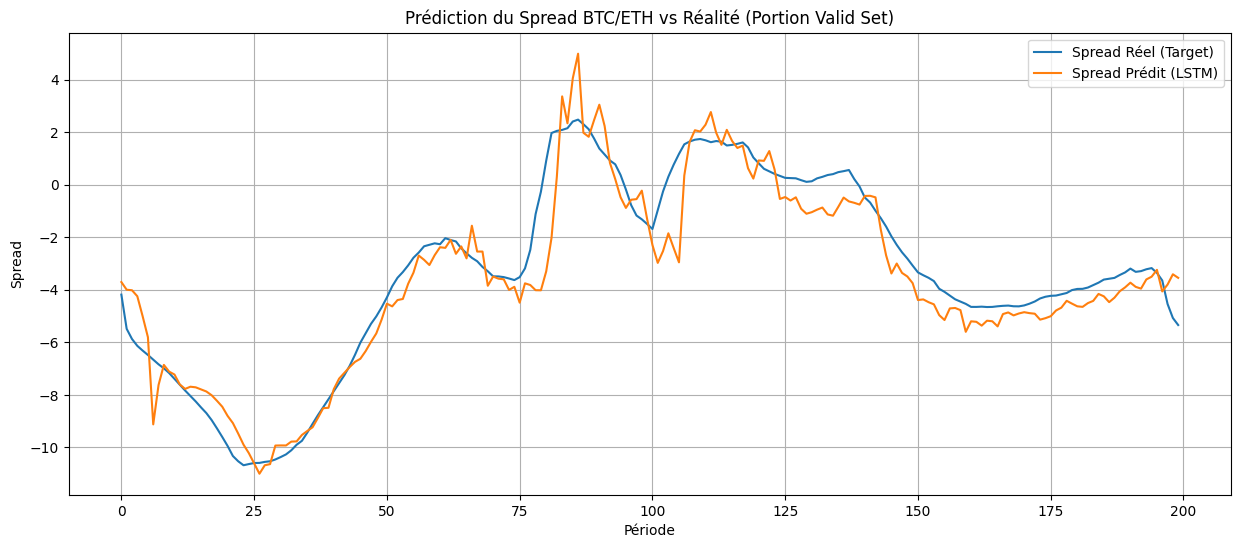

In [40]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

#  PRÉDICTION SUR L'ENSEMBLE DE validation 

# Utiliser le modèle pour prédire sur les données de test

y_pred_seq = model.predict(X_val_seq)

# La prédiction est un array 2D (N, 1), on le transforme en 1D pour la comparaison

y_pred_val = y_pred_seq.flatten()
y_true_val = y_val_seq


#  CALCUL DES MÉTRIQUES


# Root Mean Squared Error (RMSE) - Erreur moyenne de la prédiction

rmse = np.sqrt(mean_squared_error(y_true_val, y_pred_val))

# R-squared (R2) - Pourcentage de variance expliqué par le modèle

r2 = r2_score(y_true_val, y_pred_val)

print("\n= Évaluation de la Prédiction LSTM sur le Set de Validation ==")
print(f"RMSE (Root Mean Squared Error): {rmse:.6f}")
print(f"R² (Coefficient de Détermination): {r2:.4f}")


#  VISUALISATION DE LA PRÉDICTION


plt.figure(figsize=(15, 6))

# Visualiser une petite portion pour plus de clarté
start_plot = 100
end_plot = 300 
plt.plot(y_true_val[start_plot:end_plot], label='Spread Réel (Target)')
plt.plot(y_pred_val[start_plot:end_plot], label='Spread Prédit (LSTM)')
plt.title(f'Prédiction du Spread BTC/ETH vs Réalité (Portion Valid Set)')
plt.xlabel('Période')
plt.ylabel('Spread')
plt.legend()
plt.grid(True)
plt.show()





Filtre de Volatilité : Le spread est tradé uniquement lorsque la Volatilité Fixe est inférieure à sa moyenne long terme, ou lorsque le signal est très fort.

Seuil Dynamique : Utiliser la Volatilité Fixe pour ajuster le seuil d'entrée du LSTM, rendant la stratégie plus prudente lorsque l'incertitude monte.

In [41]:

#  FONCTION VIX FIXE ( mon PROXY DE VOLATILITÉ)


def add_vix_fix_feature(df, window=20):
    """Calcule le VIX Fixe (proxy de la volatilité implicite)"""
    
    #  Calcul du Range (Max(log_ETH, log_BTC) - Min(log_ETH, log_BTC))
    df['Range'] = df[['log_ETH', 'log_BTC']].max(axis=1) - df[['log_ETH', 'log_BTC']].min(axis=1)
    
    #  Volatilité (VIX Fixe) = EMA du Range
    df['VIX_Fix'] = df['Range'].ewm(span=window, adjust=False).mean()
    
    #  Moyenne Mobile (pour le filtre)
    df['VIX_MA'] = df['VIX_Fix'].rolling(window=window*2).mean() # 40 périodes (160h)
    
    df = df.dropna()
    return df

# Application :
#df_features = add_vix_fix_feature(df_features, window=20)
#FEATURES.append('VIX_Fix')
#df_ml = df_features.dropna().copy()

Stratégie et calcul de métrique


--- DIAGNOSTIC DES POSITIONS (LSTM + VIX Fixe) 
Nombre total de positions (non-zéro) : 911


= RÉSULTATS DE LA STRATÉGIE FILTRÉE LSTM + VIX FIXE (La stratégie Dayan Koffi)
Sharpe Ratio Annualisé (Stable Rate): -14.02
Max Drawdown (MDD): -207.6954 (en unités de Spread)


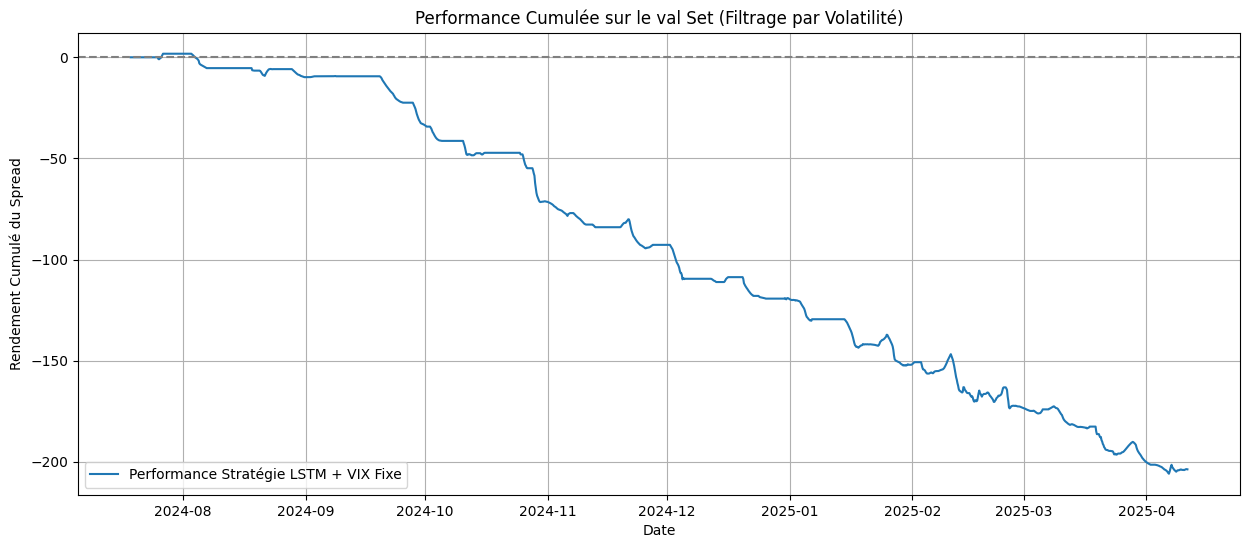

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  PARAMÈTRES 

# Le LSTM seul n'a rien tradé à 0.5, nous commençons donc à 0.3 Sigma.

Z_SCORE_ENTRY = 0.3 # Z-score minimum pour l'entrée
VIX_RISK_RATIO = 1.2 # Seuil : Si VIX_Fix > VIX_MA * 1.2, le risque est trop élevé (NON TRADABLE)

# Préparation (Alignement et Signal)

LOOKBACK = 24 
results_df = val_df.iloc[LOOKBACK:].copy()

results_df['Spread_Predicted'] = y_pred_val

# S'assurer que le VIX Fixe et sa MA sont disponibles

results_df['VIX_Fix'] = val_df['VIX_Fix'].iloc[LOOKBACK:] 
results_df['VIX_MA'] = val_df['VIX_MA'].iloc[LOOKBACK:] 

VOL_SPREAD_TEST = results_df['Spread'].std()
results_df['Signal_ZScore'] = (results_df['Spread_Predicted'] - results_df['Spread']) / VOL_SPREAD_TEST

results_df['Position'] = 0 # Initialisation


#  SIMULATION AVEC FILTRE VIX FIXE

for i in range(1, len(results_df)):
    current_signal = results_df['Signal_ZScore'].iloc[i-1]
    vix_fix = results_df['VIX_Fix'].iloc[i-1]
    vix_ma = results_df['VIX_MA'].iloc[i-1]
    previous_position = results_df['Position'].iloc[i-1]
    
    new_position = previous_position
    
    #  FILTRE DE RISQUE VIX : Vrai si la volatilité est trop élevée
    is_too_volatile = (vix_fix > vix_ma * VIX_RISK_RATIO) 
    
    # STOP-LOSS VIX : Fermer si la volatilité devient trop forte
    if previous_position != 0 and is_too_volatile:
        new_position = 0
    
    #  LOGIQUE D'ENTRÉE : Négocier uniquement si le risque est FAIBLE
    elif not is_too_volatile: 
        if current_signal > Z_SCORE_ENTRY:

            new_position = -1 # Short Spread

        elif current_signal < -Z_SCORE_ENTRY:
            new_position = 1  # Long Spread
        # Fermeture : Si le signal retombe à zéro
        elif abs(current_signal) < 0.1 * Z_SCORE_ENTRY: 
            new_position = 0
            
    results_df.loc[results_df.index[i], 'Position'] = new_position

# Forcer le type entier pour la colonne Position
results_df['Position'] = results_df['Position'].astype(int)


##  CALCUL DES RENDEMENTS, SHARPE RATIO ET MDD



results_df['Spread_Change'] = results_df['Spread'].diff()

results_df['Strategy_Returns'] = results_df['Position'].shift(1) * results_df['Spread_Change']
results_df = results_df.dropna() 

# Diagnostic 
print("\n--- DIAGNOSTIC DES POSITIONS (LSTM + VIX Fixe) ")
print(f"Nombre total de positions (non-zéro) : {(results_df['Position'] != 0).sum()}")



std_return = results_df['Strategy_Returns'].std()
if std_return == 0:
    sharpe_ratio = 0.0
else:
    mean_return = results_df['Strategy_Returns'].mean()
    ANNUALIZATION_FACTOR = np.sqrt(365 * 24 / 4) 
    sharpe_ratio = (mean_return / std_return) * ANNUALIZATION_FACTOR

results_df['Cumulative_Returns'] = results_df['Strategy_Returns'].cumsum() 

results_df['Peak'] = results_df['Cumulative_Returns'].cummax()

results_df['Drawdown'] = results_df['Cumulative_Returns'] - results_df['Peak']

max_drawdown = results_df['Drawdown'].min()

print("\n\n= RÉSULTATS DE LA STRATÉGIE FILTRÉE LSTM + VIX FIXE (La stratégie Dayan Koffi)")

print(f"Sharpe Ratio Annualisé (Stable Rate): {sharpe_ratio:.2f}")

print(f"Max Drawdown (MDD): {max_drawdown:.4f} (en unités de Spread)")


#  VISUALISATION

plt.figure(figsize=(15, 6))

plt.plot(results_df.index, results_df['Cumulative_Returns'], label='Performance Stratégie LSTM + VIX Fixe')
plt.title('Performance Cumulée sur le val Set (Filtrage par Volatilité)')
plt.xlabel('Date')
plt.ylabel('Rendement Cumulé du Spread')
plt.axhline(0, color='grey', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()



Sur les données de validation, on va inversé la logique de notre stratégie de base car on remarque que notre modèle LSTM est en retard sur la réalité (on note une bonne capacité du modèle à prédire les mouvements de marché)

ON TESTE LA LOGIQUE INVERSEE SUR LES DONNEES DE VALIDATION


 DIAGNOSTIC DES POSITIONS (LSTM + VIX Fixe INVERSÉ) 
Nombre total de positions (non-zéro) : 204


 RÉSULTATS DE LA STRATÉGIE FILTRÉE LSTM + VIX FIXE (INVERSÉE) 
Sharpe Ratio Annualisé (Stable Rate): 6.67
Max Drawdown (MDD): -6.3851 (en unités de Spread)


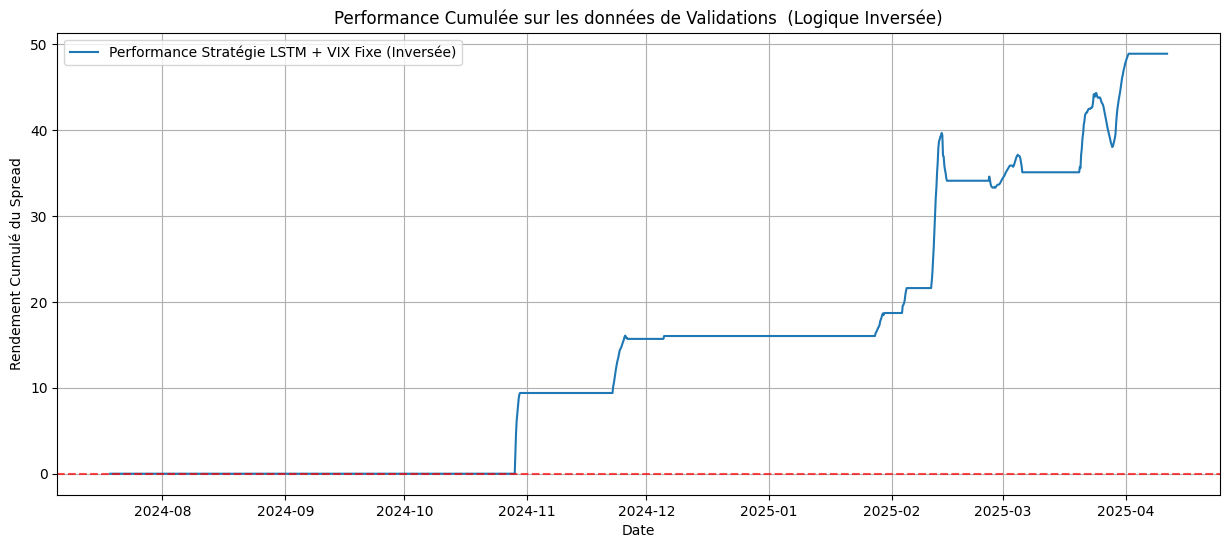

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  Les variables results_df, VOL_SPREAD_TEST, y_pred_test, VIX_Fix, VIX_MA, etc. sont supposées définies 

LOOKBACK = 24
VOL_SPREAD_TEST = results_df['Spread'].std()

#  Préparation 
LOOKBACK = 24 
results_df = val_df.iloc[LOOKBACK:].copy()
results_df['Spread_Predicted'] = y_pred_val



#  PARAMÈTRES (AGRESSIFS ET RESTRICTIFS)



Z_SCORE_ENTRY = 1.0     # AUGMENTATION : Seulement les signaux forts (1.0 Sigma)
Z_SCORE_EXIT = 0.1      # Maintient un seuil de sortie très bas (0.1 Sigma)
VIX_RISK_RATIO = 1.1    # RESTRICTION : Fermer plus facilement en cas d'augmentation du risque VIX

# Calcul du Signal Z-Score

results_df['Signal_ZScore'] = (results_df['Spread_Predicted'] - results_df['Spread']) / VOL_SPREAD_TEST
results_df['Position'] = 0.0 # Initialisation 

#  SIMULATION AVEC INVERSION DE LA LOGIQUE



for i in range(1, len(results_df)):
    current_signal = results_df['Signal_ZScore'].iloc[i-1]
    vix_fix = results_df['VIX_Fix'].iloc[i-1]
    vix_ma = results_df['VIX_MA'].iloc[i-1]
    previous_position = results_df['Position'].iloc[i-1]
    
    new_position = previous_position
    
    #  FILTRE DE RISQUE VIX : Vrai si la volatilité est trop élevée (plus restrictif)

    is_too_volatile = (vix_fix > vix_ma * VIX_RISK_RATIO) 
    
    #  STOP-LOSS VIX : Fermer si la volatilité devient trop forte

    if previous_position != 0 and is_too_volatile:
        new_position = 0.0
    
    #  LOGIQUE D'ENTRÉE : Négocier uniquement si le risque est FAIBLE

    elif not is_too_volatile: 
        
        # LOGIQUE INVERSÉE 
        if current_signal > Z_SCORE_ENTRY:
            # Signal d'achat SHORT, mais nous faisons LONG
            new_position = 1.0 
        elif current_signal < -Z_SCORE_ENTRY:
            # Signal d'achat LONG, mais nous faisons SHORT
            new_position = -1.0  
        # Fermeture : Si le signal retombe à zéro
        elif abs(current_signal) < Z_SCORE_EXIT: 
            new_position = 0.0
            
    results_df.loc[results_df.index[i], 'Position'] = new_position

results_df['Position'] = results_df['Position'].astype(int)


#  CALCUL DES RENDEMENTS, SHARPE RATIO ET MDD

results_df['Spread_Change'] = results_df['Spread'].diff()

results_df['Strategy_Returns'] = results_df['Position'].shift(1) * results_df['Spread_Change']

results_df = results_df.dropna() 

#  Diagnostic 
print("\n DIAGNOSTIC DES POSITIONS (LSTM + VIX Fixe INVERSÉ) ")
print(f"Nombre total de positions (non-zéro) : {(results_df['Position'] != 0).sum()}")


std_return = results_df['Strategy_Returns'].std()
if std_return == 0:
    sharpe_ratio = 0.0
else:
    mean_return = results_df['Strategy_Returns'].mean()
    ANNUALIZATION_FACTOR = np.sqrt(365 * 24 / 4) 
    sharpe_ratio = (mean_return / std_return) * ANNUALIZATION_FACTOR

results_df['Cumulative_Returns'] = results_df['Strategy_Returns'].cumsum() 

results_df['Peak'] = results_df['Cumulative_Returns'].cummax()

results_df['Drawdown'] = results_df['Cumulative_Returns'] - results_df['Peak']

max_drawdown = results_df['Drawdown'].min()

print("\n\n RÉSULTATS DE LA STRATÉGIE FILTRÉE LSTM + VIX FIXE (INVERSÉE) ")
print(f"Sharpe Ratio Annualisé (Stable Rate): {sharpe_ratio:.2f}")
print(f"Max Drawdown (MDD): {max_drawdown:.4f} (en unités de Spread)")


#  VISUALISATION

plt.figure(figsize=(15, 6))
plt.plot(results_df.index, results_df['Cumulative_Returns'], label='Performance Stratégie LSTM + VIX Fixe (Inversée)')
plt.title('Performance Cumulée sur les données de Validations  (Logique Inversée)')
plt.xlabel('Date')
plt.ylabel('Rendement Cumulé du Spread')
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.grid(True)
plt.legend()
plt.show()

TEST DE LA STRATEGIE AVEC LOGIQUE INVERSEE SUR LES DONNEES DE TEST

1-PREDICTION DU LSTM SUR L'ENSEMBLE DE TEST 

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

= Évaluation de la Prédiction LSTM sur le Set de Test =
RMSE (Root Mean Squared Error): 2.297973
R² (Coefficient de Détermination): 0.8644


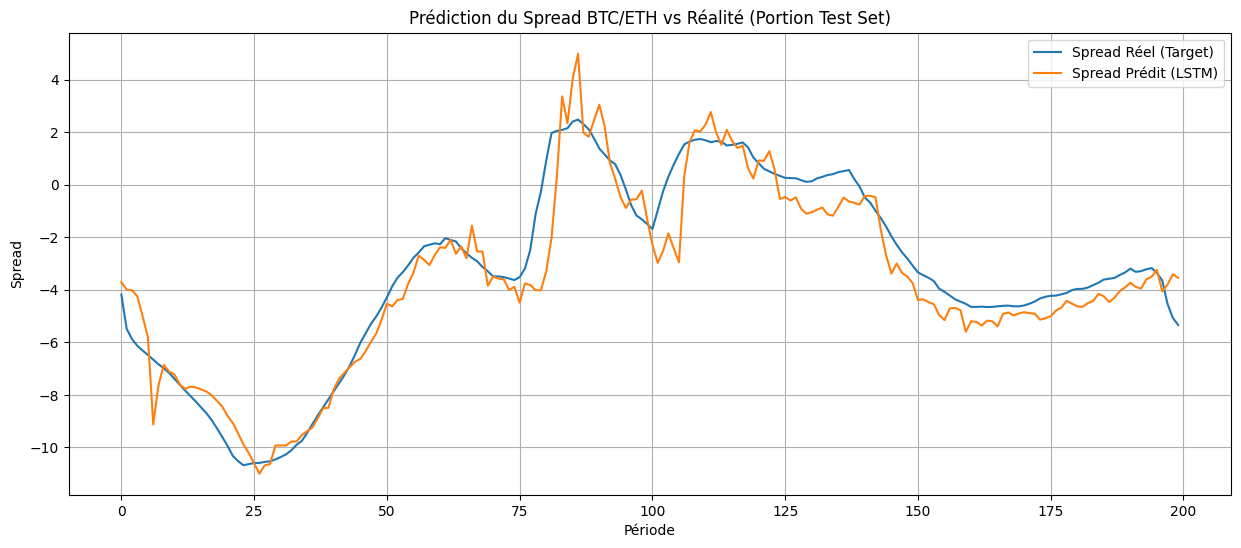

In [44]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


#  PRÉDICTION SUR L'ENSEMBLE DE TEST



# Utiliser le modèle pour prédire sur les données de test

y_pred_seq = model.predict(X_test_seq)


# La prédiction est un array 2D (N, 1), on le transforme en 1D pour la comparaison

y_pred_test = y_pred_seq.flatten()
y_true_test = y_test_seq

#  CALCUL DES MÉTRIQUES

# Root Mean Squared Error (RMSE) - Erreur moyenne de la prédiction

rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))

# R-squared (R2) - Pourcentage de variance expliqué par le modèle

r2 = r2_score(y_true_test, y_pred_test)

print("\n= Évaluation de la Prédiction LSTM sur le Set de Test =")
print(f"RMSE (Root Mean Squared Error): {rmse:.6f}")
print(f"R² (Coefficient de Détermination): {r2:.4f}")


#  VISUALISATION DE LA PRÉDICTION

plt.figure(figsize=(15, 6))

# Visualiser une petite portion pour plus de clarté

start_plot = 100
end_plot = 300 
plt.plot(y_true_test[start_plot:end_plot], label='Spread Réel (Target)')
plt.plot(y_pred_test[start_plot:end_plot], label='Spread Prédit (LSTM)')
plt.title(f'Prédiction du Spread BTC/ETH vs Réalité (Portion Test Set)')
plt.xlabel('Période')
plt.ylabel('Spread')
plt.legend()
plt.grid(True)
plt.show()








--- DIAGNOSTIC DES POSITIONS (LSTM + VIX Fixe INVERSÉ) ---
Nombre total de positions (non-zéro) : 1312


=== RÉSULTATS DE LA STRATÉGIE FILTRÉE LSTM + VIX FIXE (INVERSÉE) ===
Sharpe Ratio Annualisé (Stable Rate): 4.54
Max Drawdown (MDD): -40.0243 (en unités de Spread)


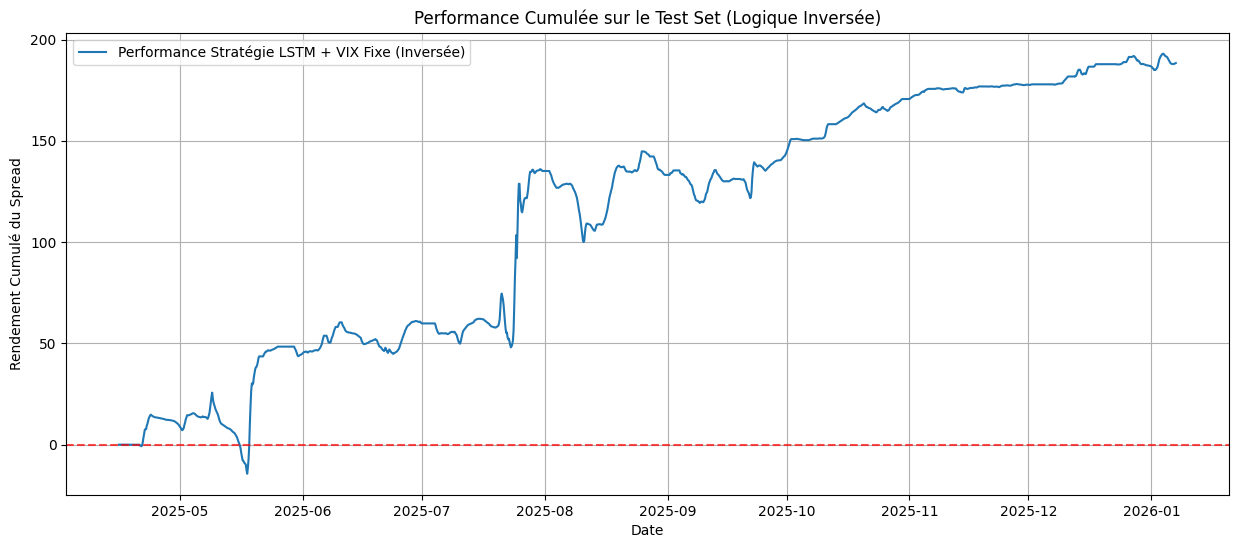

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#  PARAMÈTRES On peut Ajuster ces seuils si nécessaire après le premier run




Z_SCORE_ENTRY = 0.3 # Z-score minimum pour l'entrée
VIX_RISK_RATIO = 1.2 # Seuil : Si VIX_Fix > VIX_MA * 1.2, le risque est trop élevé (NON TRADABLE)

# --- Préparation (Alignement et Signal) ---

LOOKBACK = 24 
# Alignement strict

results_df2 = test_df.iloc[LOOKBACK:LOOKBACK + len(y_pred_test)].copy()

# Assignation propre

results_df2['Spread_Predicted'] = y_pred_test


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



LOOKBACK = 24
VOL_SPREAD_TEST = results_df2['Spread'].std()


# Calcul du Signal Z-Score
results_df2['Signal_ZScore'] = (results_df2['Spread_Predicted'] - results_df2['Spread']) / VOL_SPREAD_TEST
results_df2['Position'] = 0.0 # Initialisation 


#  SIMULATION AVEC INVERSION DE LA LOGIQUE

for i in range(1, len(results_df2)):
    current_signal = results_df2['Signal_ZScore'].iloc[i-1]
    vix_fix = results_df2['VIX_Fix'].iloc[i-1]
    vix_ma = results_df2['VIX_MA'].iloc[i-1]
    previous_position = results_df2['Position'].iloc[i-1]
    
    new_position = previous_position
    
    #  FILTRE DE RISQUE VIX : Vrai si la volatilité est trop élevée (plus restrictif)
    is_too_volatile = (vix_fix > vix_ma * VIX_RISK_RATIO) 
    
    #  STOP-LOSS VIX : Fermer si la volatilité devient trop forte
    if previous_position != 0 and is_too_volatile:
        new_position = 0.0
    
    #  LOGIQUE D'ENTRÉE : Négocier uniquement si le risque est FAIBLE
    elif not is_too_volatile: 
        
        #  LOGIQUE INVERSÉE (Correction du Retard) 
        if current_signal > Z_SCORE_ENTRY:
            # Signal d'achat SHORT, mais nous faisons LONG
            new_position = 1.0 
        elif current_signal < -Z_SCORE_ENTRY:
            # Signal d'achat LONG, mais nous faisons SHORT
            new_position = -1.0  
        # Fermeture : Si le signal retombe à zéro
        elif abs(current_signal) < Z_SCORE_EXIT: 
            new_position = 0.0
            
    results_df2.loc[results_df2.index[i], 'Position'] = new_position

results_df2['Position'] = results_df2['Position'].astype(int)


#  CALCUL DES RENDEMENTS, SHARPE RATIO ET MDD


results_df2['Spread_Change'] = results_df2['Spread'].diff()
results_df2['Strategy_Returns'] = results_df2['Position'].shift(1) * results_df2['Spread_Change']
results_df2 = results_df2.dropna() 

# Diagnostic 
print("\n--- DIAGNOSTIC DES POSITIONS (LSTM + VIX Fixe INVERSÉ) ---")
print(f"Nombre total de positions (non-zéro) : {(results_df2['Position'] != 0).sum()}")


std_return = results_df2['Strategy_Returns'].std()
if std_return == 0:
    sharpe_ratio = 0.0
else:
    mean_return = results_df2['Strategy_Returns'].mean()
    ANNUALIZATION_FACTOR = np.sqrt(365 * 24 / 4) 
    sharpe_ratio = (mean_return / std_return) * ANNUALIZATION_FACTOR      # calacul of sharpe ratio

results_df2['Cumulative_Returns'] = results_df2['Strategy_Returns'].cumsum() 
results_df2['Peak'] = results_df2['Cumulative_Returns'].cummax()

results_df2['Drawdown'] = results_df2['Cumulative_Returns'] - results_df2['Peak']
max_drawdown = results_df2['Drawdown'].min()

print("\n\n=== RÉSULTATS DE LA STRATÉGIE FILTRÉE LSTM + VIX FIXE (INVERSÉE) ===")
print(f"Sharpe Ratio Annualisé (Stable Rate): {sharpe_ratio:.2f}")
print(f"Max Drawdown (MDD): {max_drawdown:.4f} (en unités de Spread)")


#  VISUALISATION

plt.figure(figsize=(15, 6))
plt.plot(results_df2.index, results_df2['Cumulative_Returns'], label='Performance Stratégie LSTM + VIX Fixe (Inversée)')
plt.title('Performance Cumulée sur le Test Set (Logique Inversée)')
plt.xlabel('Date')
plt.ylabel('Rendement Cumulé du Spread')
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.grid(True)
plt.legend()
plt.show()

In [46]:
print(results_df2["Strategy_Returns"])

timestamp
2025-04-15 16:00:00    0.000000
2025-04-15 20:00:00    0.000000
2025-04-16 00:00:00    0.000000
2025-04-16 04:00:00    0.000000
2025-04-16 08:00:00    0.000000
                         ...   
2026-01-06 12:00:00   -0.087896
2026-01-06 16:00:00    0.106273
2026-01-06 20:00:00    0.104730
2026-01-07 00:00:00    0.185662
2026-01-07 04:00:00    0.162536
Name: Strategy_Returns, Length: 1600, dtype: float64


In [47]:
print(results_df2["Cumulative_Returns"])

timestamp
2025-04-15 16:00:00      0.000000
2025-04-15 20:00:00      0.000000
2025-04-16 00:00:00      0.000000
2025-04-16 04:00:00      0.000000
2025-04-16 08:00:00      0.000000
                          ...    
2026-01-06 12:00:00    187.836913
2026-01-06 16:00:00    187.943186
2026-01-06 20:00:00    188.047916
2026-01-07 00:00:00    188.233578
2026-01-07 04:00:00    188.396114
Name: Cumulative_Returns, Length: 1600, dtype: float64


LES RENDEMENTS CUMULES SONT EN UNITE DE SPREAD

EXTRACTION DE LA SERIE DE POSITION

In [48]:

#  EXTRACTION DE LA SÉRIE DES POSITIONS


# On sélectionne les colonnes clés pour comprendre chaque décision
series_positions = results_df2[['Spread', 'Signal_ZScore', 'VIX_Fix', 'Position']].copy()

# Ajouter une colonne descriptive pour plus de clarté

series_positions['Label_Position'] = series_positions['Position'].map({1: 'LONG', -1: 'SHORT', 0: 'FLAT (Aucun)'})

# Filtrer pour ne voir que les moments où la position CHANGE (pour éviter les doublons inutiles)

changements_positions = series_positions[series_positions['Position'] != series_positions['Position'].shift(1)]

# Affichage des 20 premières lignes du DataFrame des positions

print("\n--- EXTRAIT DU DATAFRAME DES POSITIONS ---")
print(series_positions.head(20))

# --- OPTIONNEL : Export pour analyse Excel ---
#series_positions.to_csv("positions_model_lstm.csv")


--- EXTRAIT DU DATAFRAME DES POSITIONS ---
                       Spread  Signal_ZScore   VIX_Fix  Position  \
timestamp                                                          
2025-04-15 16:00:00 -4.071427       0.194539  3.953489         0   
2025-04-15 20:00:00 -3.809048       0.171165  3.954452         0   
2025-04-16 00:00:00 -3.407657       0.128413  3.955247         0   
2025-04-16 04:00:00 -3.045581       0.089114  3.957203         0   
2025-04-16 08:00:00 -2.708029       0.056214  3.958548         0   
2025-04-16 12:00:00 -2.413455       0.027144  3.960275         0   
2025-04-16 16:00:00 -2.157160       0.026992  3.961385         0   
2025-04-16 20:00:00 -2.280444       0.064652  3.962735         0   
2025-04-17 00:00:00 -2.429782       0.089794  3.963448         0   
2025-04-17 04:00:00 -2.562765       0.113632  3.963859         0   
2025-04-17 08:00:00 -2.525539       0.122111  3.964605         0   
2025-04-17 12:00:00 -2.447696       0.123844  3.965852         0   
2025

<Axes: xlabel='timestamp'>

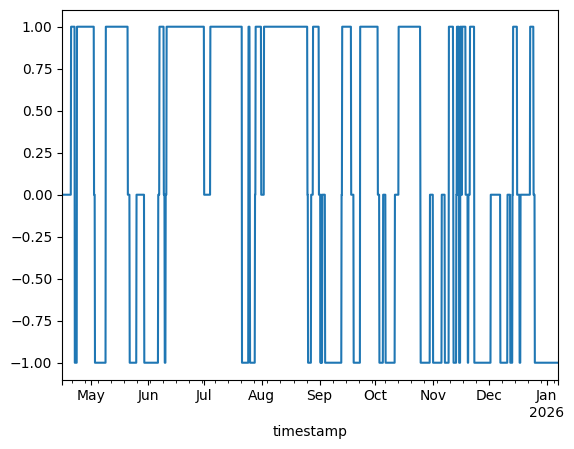

In [49]:
series_positions.Position.plot()

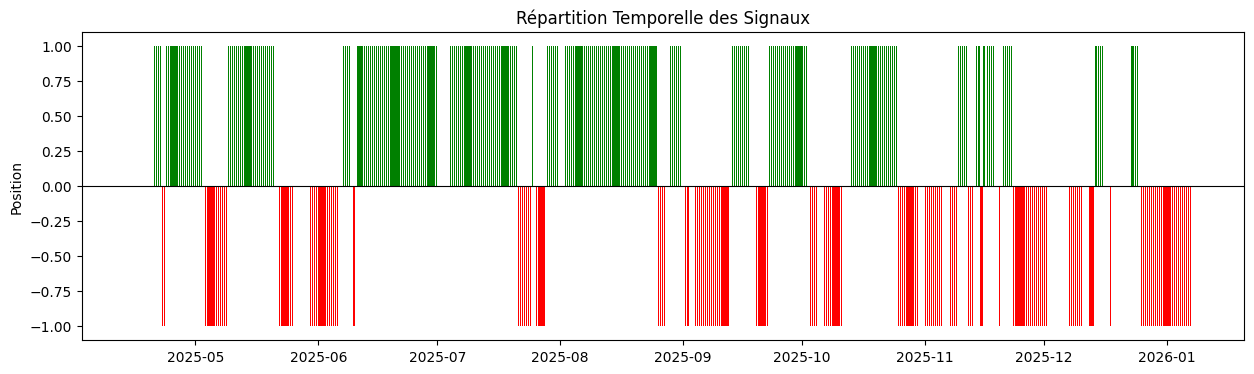

In [50]:
plt.figure(figsize=(15, 4))

# Utilisation de barres très fines pour simuler une continuité
plt.bar(series_positions.index, series_positions.Position, width=0.1, 
        color=['green' if x > 0 else 'red' if x < 0 else 'gray' for x in series_positions.Position])

plt.title("Répartition Temporelle des Signaux")
plt.ylabel("Position")
plt.axhline(0, color='black', linewidth=0.8)
plt.show()


--- NATURE DES POSITIONS ET PERFORMANCE PAR MOIS 
            Bougies_Long  Bougies_Short  Bougies_Flat   PnL_Long  PnL_Short
timestamp                                                                  
2025-04-30            56              7            29   2.782437   6.635586
2025-05-31            82             70            34  22.714366  10.282931
2025-06-30           135             35            10   3.570747   9.537896
2025-07-31           124             37            25  44.348914  20.969303
2025-08-31           159             10            17  -1.307366  -1.888632
2025-09-30            78             79            23   1.588885   7.473601
2025-10-31            78             72            36  15.170114  10.839128
2025-11-30            48            103            29   2.742126   4.187337
2025-12-31            24             77            85   1.721801   5.469357
2026-01-31             0             38             0        NaN   1.610669


C:\Users\koffi\AppData\Local\Temp\ipykernel_45096\2108977816.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  nature_mensuelle['Bougies_Long'] = results_df2['Is_Long'].resample('M').sum()
C:\Users\koffi\AppData\Local\Temp\ipykernel_45096\2108977816.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  nature_mensuelle['Bougies_Short'] = results_df2['Is_Short'].resample('M').sum()
C:\Users\koffi\AppData\Local\Temp\ipykernel_45096\2108977816.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  nature_mensuelle['Bougies_Flat'] = results_df2['Is_Flat'].resample('M').sum()
C:\Users\koffi\AppData\Local\Temp\ipykernel_45096\2108977816.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  nature_mensuelle['PnL_Long'] = (results_df2[results_df2['Position'] == 1]['Strategy_Retu

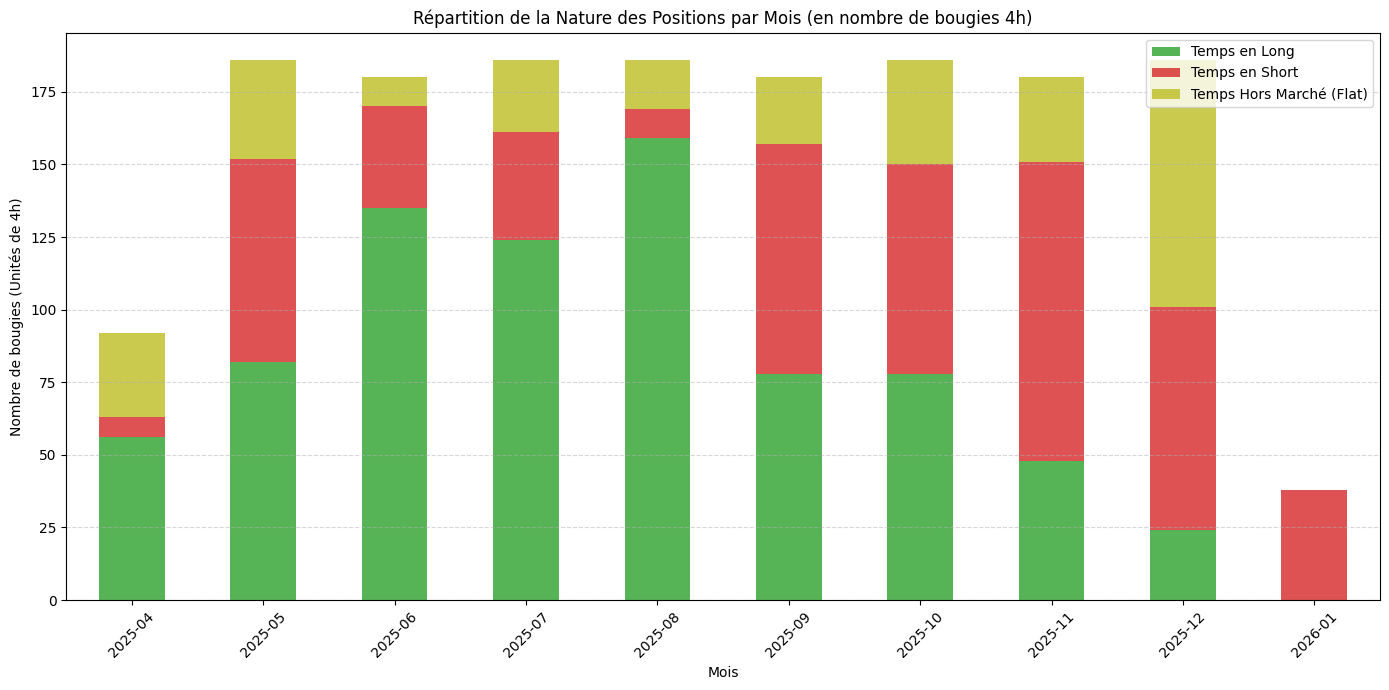

In [51]:

#ANALYSE DE LA NATURE DES POSITIONS PAR MOIS


# 1. Création des indicateurs de nature de position

results_df2['Is_Long'] = (results_df2['Position'] == 1).astype(int)

results_df2['Is_Short'] = (results_df2['Position'] == -1).astype(int)

results_df2['Is_Flat'] = (results_df2['Position'] == 0).astype(int)

# 2. Rééchantillonnage mensuel (en nombre de bougies de 4h)

nature_mensuelle = pd.DataFrame()

nature_mensuelle['Bougies_Long'] = results_df2['Is_Long'].resample('M').sum()

nature_mensuelle['Bougies_Short'] = results_df2['Is_Short'].resample('M').sum()

nature_mensuelle['Bougies_Flat'] = results_df2['Is_Flat'].resample('M').sum()

# Calcul du P&L par nature pour voir ce qui rapporte le plus

nature_mensuelle['PnL_Long'] = (results_df2[results_df2['Position'] == 1]['Strategy_Returns']).resample('M').sum().fillna(0)

nature_mensuelle['PnL_Short'] = (results_df2[results_df2['Position'] == -1]['Strategy_Returns']).resample('M').sum().fillna(0)

# 3. Affichage du tableau de bord

print("\n--- NATURE DES POSITIONS ET PERFORMANCE PAR MOIS ")
print(nature_mensuelle)

# 4. Graphique de répartition 

ax = nature_mensuelle[['Bougies_Long', 'Bougies_Short', 'Bougies_Flat']].plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 7),
    color=['#2ca02c', '#d62728', '#bcbd22'],
    alpha=0.8
)

plt.title('Répartition de la Nature des Positions par Mois (en nombre de bougies 4h)')
plt.xlabel('Mois')
plt.ylabel('Nombre de bougies (Unités de 4h)')
plt.legend(['Temps en Long', 'Temps en Short', 'Temps Hors Marché (Flat)'])
plt.xticks(range(len(nature_mensuelle)), nature_mensuelle.index.strftime('%Y-%m'), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\koffi\AppData\Local\Temp\ipykernel_45096\3964109238.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  perf_mensuelle['Gains_Long'] = results_df2['PnL_Long'].resample('M').sum()
C:\Users\koffi\AppData\Local\Temp\ipykernel_45096\3964109238.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  perf_mensuelle['Gains_Short'] = results_df2['PnL_Short'].resample('M').sum()
C:\Users\koffi\AppData\Local\Temp\ipykernel_45096\3964109238.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  perf_mensuelle['Gains_Totaux'] = results_df2['Strategy_Returns'].resample('M').sum()


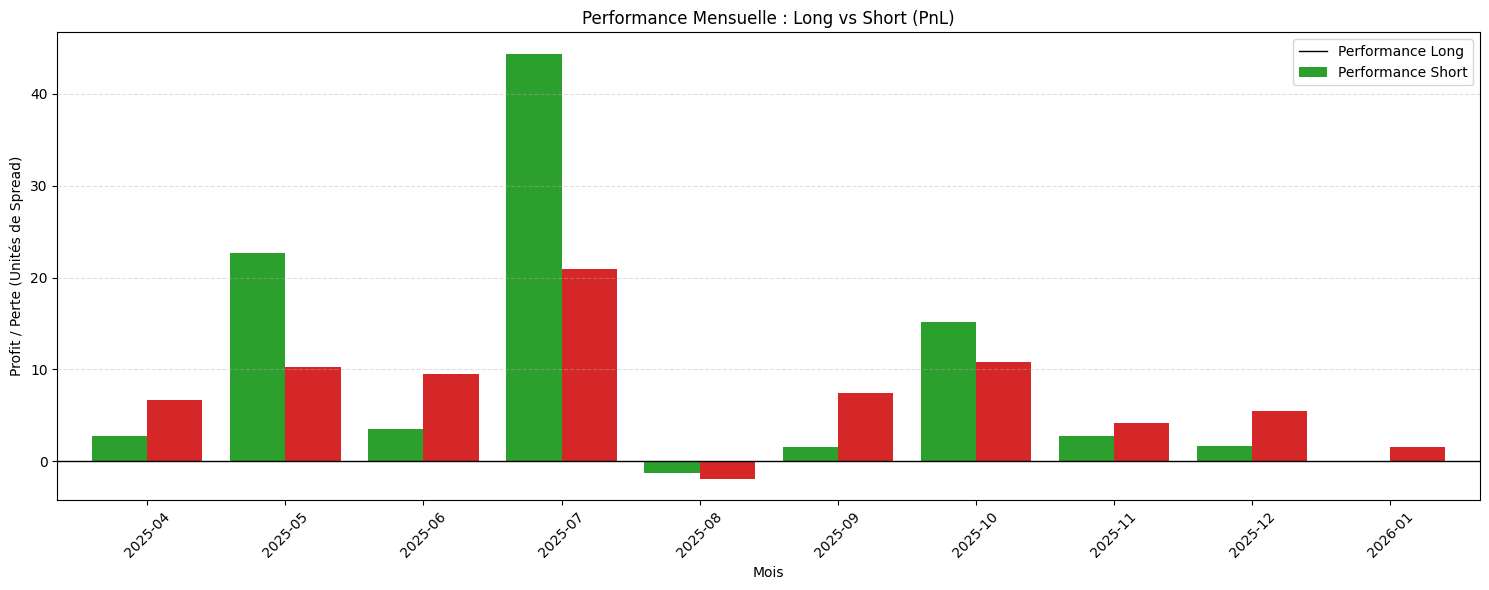

In [52]:
import matplotlib.pyplot as plt
import pandas as pd


#   PRÉPARATION DES DONNÉES MENSUELLES


# Calcul du PnL séparé par nature

results_df2['PnL_Long'] = np.where(results_df2['Position'] == 1, results_df2['Strategy_Returns'], 0)
results_df2['PnL_Short'] = np.where(results_df2['Position'] == -1, results_df2['Strategy_Returns'], 0)

# Groupe par mois pour les performances

perf_mensuelle = pd.DataFrame()
perf_mensuelle['Gains_Long'] = results_df2['PnL_Long'].resample('M').sum()
perf_mensuelle['Gains_Short'] = results_df2['PnL_Short'].resample('M').sum()
perf_mensuelle['Gains_Totaux'] = results_df2['Strategy_Returns'].resample('M').sum()


#  2. HISTOGRAMME DE PERFORMANCE PAR NATURE (MOIS PAR MOIS)

ax = perf_mensuelle[['Gains_Long', 'Gains_Short']].plot(
    kind='bar', 
    figsize=(15, 6),
    color=['#2ca02c', '#d62728'], # Vert pour Long, Rouge pour Short
    width=0.8
)

plt.title('Performance Mensuelle : Long vs Short (PnL)')
plt.xlabel('Mois')
plt.ylabel('Profit / Perte (Unités de Spread)')
plt.axhline(0, color='black', linewidth=1) # Ligne de zéro
plt.xticks(range(len(perf_mensuelle)), perf_mensuelle.index.strftime('%Y-%m'), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(['Performance Long', 'Performance Short'])
plt.tight_layout()
plt.show()



In [53]:
print(results_df2['PnL_Long'])

timestamp
2025-04-15 16:00:00    0.0
2025-04-15 20:00:00    0.0
2025-04-16 00:00:00    0.0
2025-04-16 04:00:00    0.0
2025-04-16 08:00:00    0.0
                      ... 
2026-01-06 12:00:00    0.0
2026-01-06 16:00:00    0.0
2026-01-06 20:00:00    0.0
2026-01-07 00:00:00    0.0
2026-01-07 04:00:00    0.0
Name: PnL_Long, Length: 1600, dtype: float64


In [54]:
print(results_df2['PnL_Short'])

timestamp
2025-04-15 16:00:00    0.000000
2025-04-15 20:00:00    0.000000
2025-04-16 00:00:00    0.000000
2025-04-16 04:00:00    0.000000
2025-04-16 08:00:00    0.000000
                         ...   
2026-01-06 12:00:00   -0.087896
2026-01-06 16:00:00    0.106273
2026-01-06 20:00:00    0.104730
2026-01-07 00:00:00    0.185662
2026-01-07 04:00:00    0.162536
Name: PnL_Short, Length: 1600, dtype: float64


In [55]:

#  MÉTA-BACKTEST : PROFIT NET ET MÉTRIQUES DE RISQUE


def calculate_advanced_meta(df):
    meta_reports = []
    grouped = df.groupby(pd.Grouper(freq='M'))
    
    # Facteur d'annualisation pour du 4h (6 bougies/jour, 365 jours)

    ANNUAL_FACTOR = np.sqrt(365 * 6) 
    cumulative_pnl = 0 # Initialisation du profit global
    
    for month, data in grouped:
        if len(data) < 10: continue
        
        returns = data['Strategy_Returns']
        
        # 1. PROFIT NET DU MOIS (En unités de spread)
        
        monthly_net_profit = returns.sum()
        cumulative_pnl += monthly_net_profit # Somme au fil des mois
        
        # 2. SHARPE RATIO
        std_dev = returns.std()
        sharpe = (returns.mean() / std_dev) * ANNUAL_FACTOR if std_dev != 0 else 0
        
        # 3. SORTINO RATIO
        downside_returns = returns[returns < 0]
        downside_std = downside_returns.std()
        sortino = (returns.mean() / downside_std) * ANNUAL_FACTOR if downside_std != 0 else 0
        
        # 4. MAX DRAWDOWN (Interne au mois)
        cum_ret_month = returns.cumsum()
        mdd = (cum_ret_month - cum_ret_month.cummax()).min()
        
        meta_reports.append({
            'Mois': month.strftime('%Y-%m'),
            'Profit_Net_Spread': round(monthly_net_profit, 4),
            'Profit_Cumulé_Total': round(cumulative_pnl, 4),
            'Sharpe': round(sharpe, 2),
            'Sortino': round(sortino, 2),
            'Max_Drawdown': round(mdd, 4)
        })
    
    return pd.DataFrame(meta_reports)

# Exécution
df_meta_final = calculate_advanced_meta(results_df2)

# Affichage propre
print("\n--- RAPPORT DE PERFORMANCE (UNITÉS DE SPREAD) ---")
print(df_meta_final.to_string(index=False))


--- RAPPORT DE PERFORMANCE (UNITÉS DE SPREAD) ---
   Mois  Profit_Net_Spread  Profit_Cumulé_Total  Sharpe  Sortino  Max_Drawdown
2025-04             9.4180               9.4180    9.23    41.70       -5.3944
2025-05            35.3776              44.7956    5.68    15.27      -40.0243
2025-06            15.3451              60.1407    7.67    12.64      -15.5605
2025-07            74.9611             135.1018    6.69    10.77      -26.5553
2025-08            -1.9343             133.1675   -0.52    -0.74      -35.1014
2025-09            10.4564             143.6239    3.27     7.01      -16.0533
2025-10            27.0056             170.6295   20.82    44.64       -4.4421
2025-11             7.0607             177.6903   11.61    19.27       -2.0765
2025-12             9.0952             186.7854    8.39    10.03       -5.0499
2026-01             1.6107             188.3961    3.69     9.62       -5.1563


C:\Users\koffi\AppData\Local\Temp\ipykernel_45096\1932336292.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouped = df.groupby(pd.Grouper(freq='M'))


 une "Unité de Spread" ? 
 par exemple Si le spread passe de 100 à 105, je gagne  5 unités. Mon tableau indique qu'en juillet, j'aurais capturé 83.93 unités de mouvement.

On va comparer le sortino et le sharpe, Si le Sortino est beaucoup plus élevé que le Sharpe, cela signifie que notre stratégie a une "bonne" volatilité (des hausses rapides) et peu de "mauvaise" volatilité (chutes brutales).

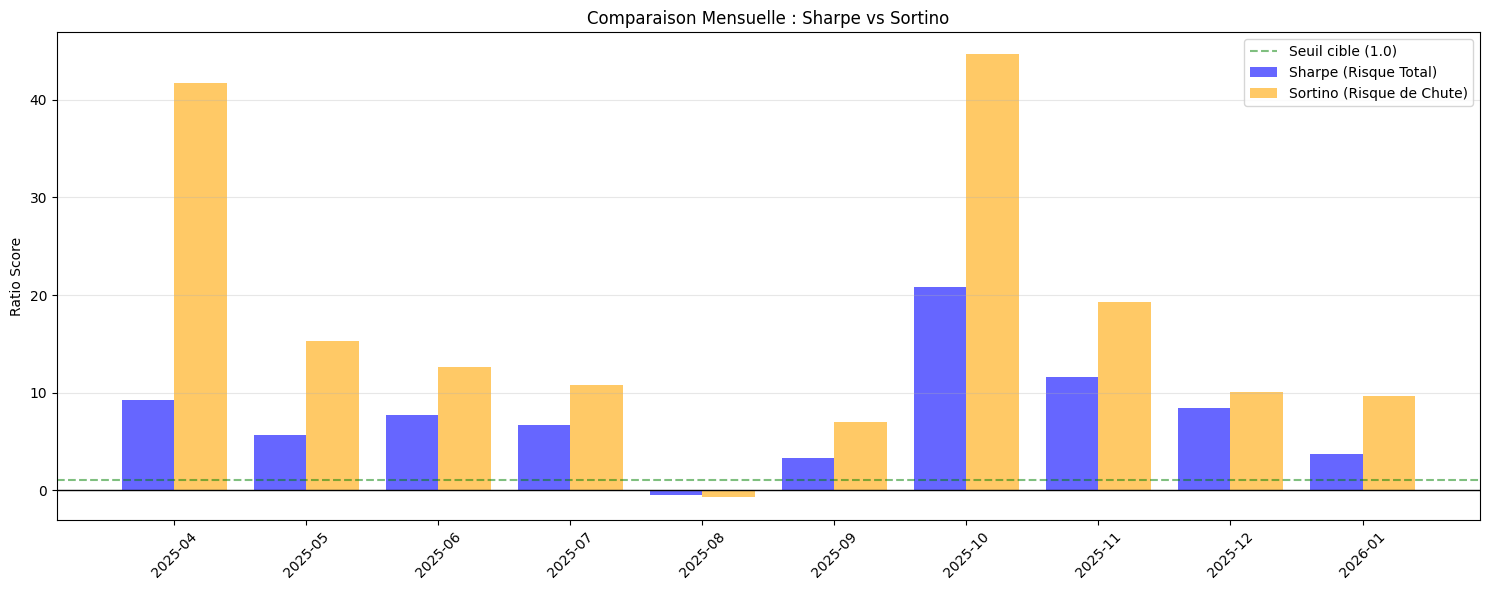

In [56]:
plt.figure(figsize=(15, 6))
x = range(len(df_meta_final))

plt.bar(x, df_meta_final['Sharpe'], width=0.4, label='Sharpe (Risque Total)', color='blue', alpha=0.6)
plt.bar([i + 0.4 for i in x], df_meta_final['Sortino'], width=0.4, label='Sortino (Risque de Chute)', color='orange', alpha=0.6)

plt.xticks([i + 0.2 for i in x], df_meta_final['Mois'], rotation=45)
plt.axhline(0, color='black', linewidth=1)
plt.axhline(1, color='green', linestyle='--', alpha=0.5, label='Seuil cible (1.0)')

plt.title('Comparaison Mensuelle : Sharpe vs Sortino')
plt.ylabel('Ratio Score')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

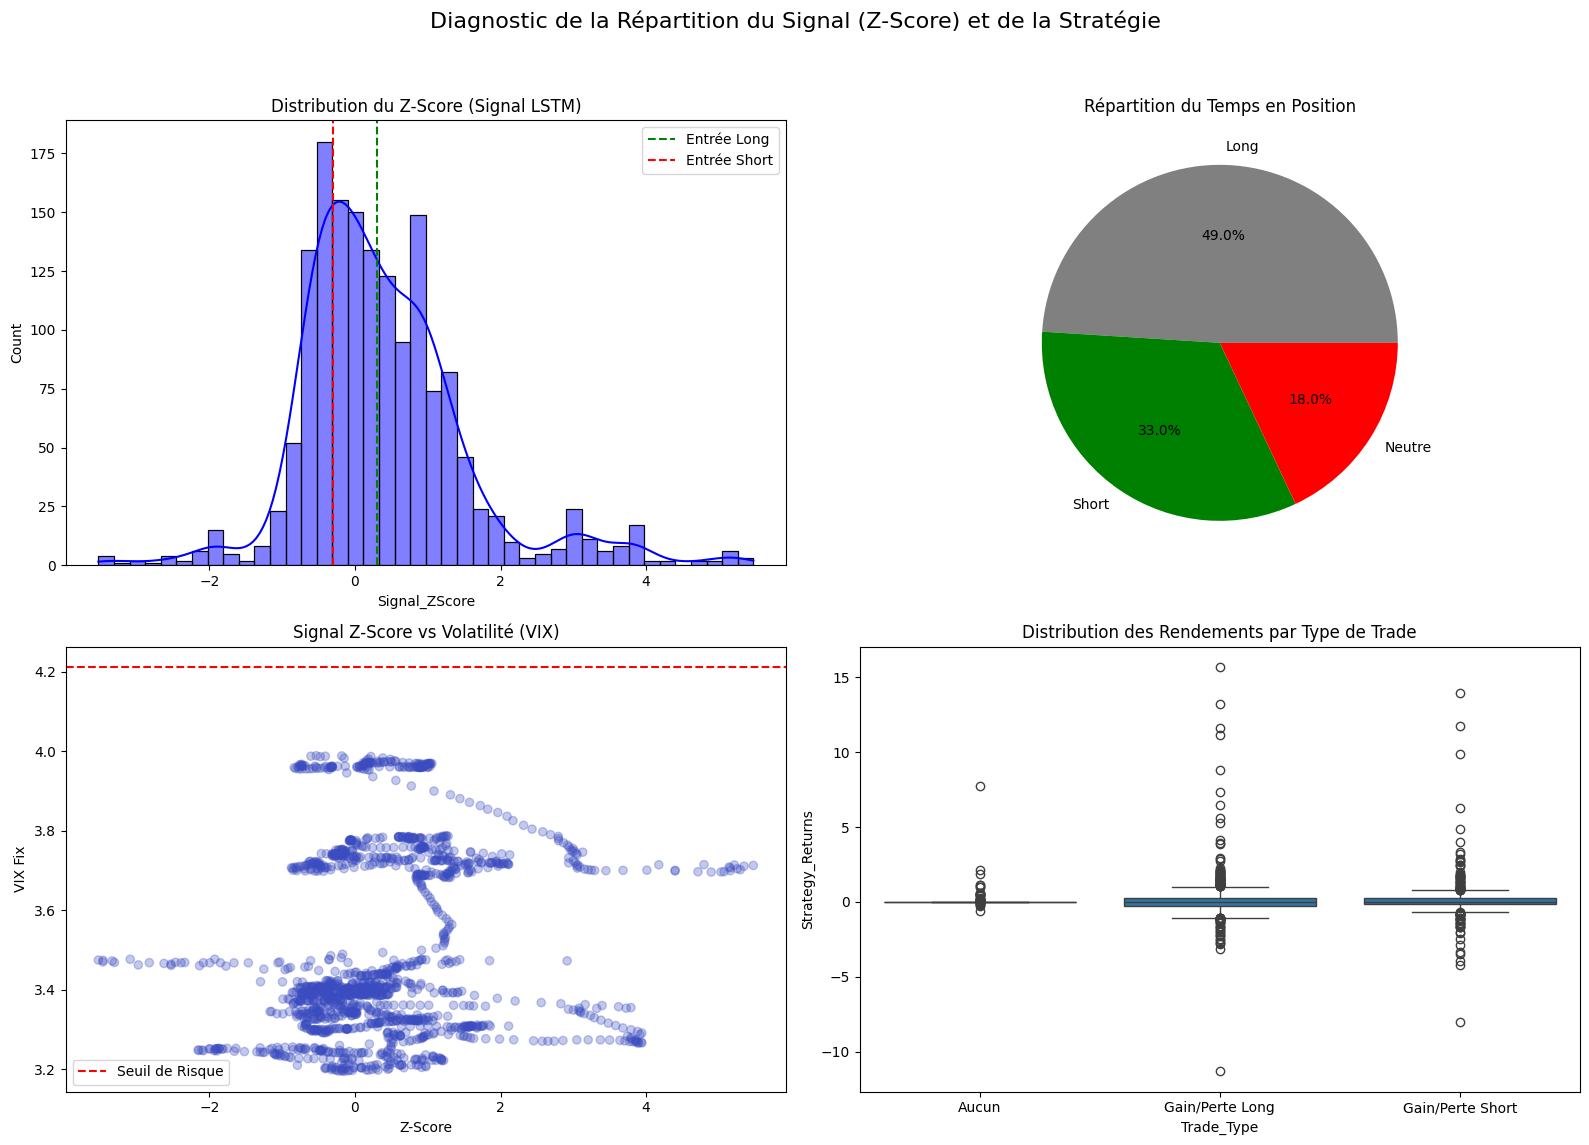


--- STATISTIQUES DE RÉPARTITION ---
Z-Score Moyen : 0.3864
Z-Score Max/Min : 5.47 / -3.53
Pourcentage de temps exposé au marché : 82.00%


In [57]:

#  ANALYSE DE LA RÉPARTITION DU SIGNAL ET DES POSITIONS


import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Diagnostic de la Répartition du Signal (Z-Score) et de la Stratégie', fontsize=16)

#  Distribution du Z-Score (Current Signal)

sns.histplot(results_df2['Signal_ZScore'], kde=True, ax=axes[0, 0], color='blue')

axes[0, 0].axvline(Z_SCORE_ENTRY, color='green', linestyle='--', label='Entrée Long')

axes[0, 0].axvline(-Z_SCORE_ENTRY, color='red', linestyle='--', label='Entrée Short')

axes[0, 0].set_title('Distribution du Z-Score (Signal LSTM)')
axes[0, 0].legend()

#  Répartition des types de positions

position_counts = results_df2['Position'].value_counts()
labels = {1: 'Long', -1: 'Short', 0: 'Neutre'}
position_counts.index = [labels.get(x, x) for x in position_counts.index]
position_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[0, 1], colors=['gray', 'green', 'red'])
axes[0, 1].set_title('Répartition du Temps en Position')
axes[0, 1].set_ylabel('')

#  Relation Signal vs Volatilité (VIX)

# Pour voir si le VIX bloque les gros signaux

axes[1, 0].scatter(results_df2['Signal_ZScore'], results_df2['VIX_Fix'], alpha=0.3, c=(results_df2['VIX_Fix'] > results_df2['VIX_MA'] * VIX_RISK_RATIO), cmap='coolwarm')
axes[1, 0].axhline(results_df2['VIX_MA'].mean() * VIX_RISK_RATIO, color='red', linestyle='--', label='Seuil de Risque')
axes[1, 0].set_title('Signal Z-Score vs Volatilité (VIX)')
axes[1, 0].set_xlabel('Z-Score')
axes[1, 0].set_ylabel('VIX Fix')
axes[1, 0].legend()

# 4. Évolution des Rendements par État

results_df2['Trade_Type'] = results_df2['Position'].map({1: 'Gain/Perte Long', -1: 'Gain/Perte Short', 0: 'Aucun'})
sns.boxplot(x='Trade_Type', y='Strategy_Returns', data=results_df2, ax=axes[1, 1])
axes[1, 1].set_title('Distribution des Rendements par Type de Trade')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Affichage des statistiques de répartition ---
print(f"\n--- STATISTIQUES DE RÉPARTITION ---")
print(f"Z-Score Moyen : {results_df2['Signal_ZScore'].mean():.4f}")
print(f"Z-Score Max/Min : {results_df2['Signal_ZScore'].max():.2f} / {results_df2['Signal_ZScore'].min():.2f}")
print(f"Pourcentage de temps exposé au marché : {(results_df2['Position'] != 0).mean()*100:.2f}%")